In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [2]:
df=pd.read_csv('netflix_customer_churn.csv')

In [3]:
df.sample(5)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
492,cc539484-c58e-4f2a-8d71-499afab22937,45,Male,Premium,3.31,34,Oceania,Tablet,17.99,1,Gift Card,2,0.09,Drama
2700,6e160b44-363a-4d57-bab6-5b22e979e887,56,Female,Basic,0.40,38,Oceania,Mobile,8.99,1,Debit Card,5,0.01,Action
519,bf910ef4-cb21-4375-a624-e57cc2e4c293,26,Other,Basic,0.06,2,South America,TV,8.99,1,Credit Card,4,0.02,Action
1348,6c9f98ff-4f0f-4639-85d0-5e401d743a4c,52,Male,Basic,0.41,48,Europe,TV,8.99,1,Credit Card,5,0.01,Documentary
1747,803ceff0-36a0-4703-bf52-cad1d975542f,53,Male,Basic,0.09,18,Africa,Mobile,8.99,1,PayPal,3,0.00,Comedy


In [4]:
df1=df.head(15)

don't need cust id for prediction

In [5]:
print(df.columns.tolist())

['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']


In [6]:
df.drop(columns=['device'],inplace=True)

In [7]:
df.sample()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
3514,dc8a8278-a2ed-47b1-aa4f-c0693a216b8f,63,Male,Standard,11.89,52,Europe,13.99,1,Debit Card,1,0.22,Romance


<Axes: xlabel='age', ylabel='watch_hours'>

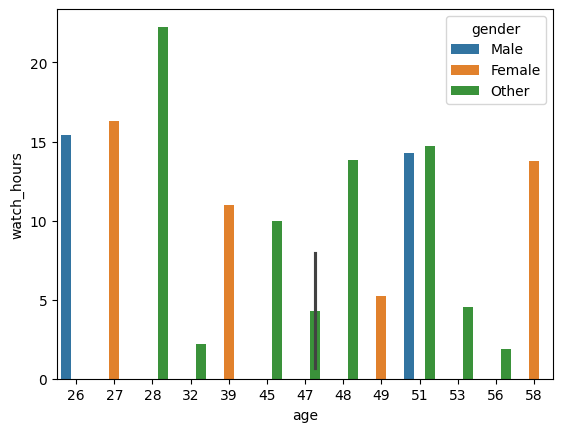

In [8]:
sns.barplot(x=df1['age'],y=df1['watch_hours'],hue=df1['gender'])

<Axes: xlabel='age', ylabel='watch_hours'>

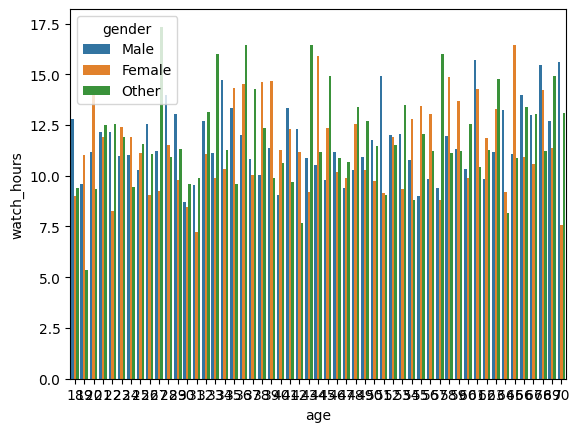

In [9]:
#If for one gender age combination you have multiple watch_hours values then black line comes
sns.barplot(x=df['age'],y=df['watch_hours'],hue=df['gender'],errorbar=None)

In [10]:
from pandas_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

/var/folders/jn/s62c2mts3mz_wcdyhpyzcgtc0000gn/T/ipykernel_31287/4209343599.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████| 13/13 [00:00<00:00, 386.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [422]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['churned']),df['churned'],test_size=0.2,random_state=42)

In [441]:
X_train = X_train.drop(columns=['payment_method'])
X_test = X_test.drop(columns=['payment_method'])

In [442]:
X_train.sample(6)

,age,gender,subscription_type,watch_hours,last_login_days,region,monthly_fee,number_of_profiles,avg_watch_time_per_day,favorite_genre
928,58,Other,Basic,14.30,43,South America,8.99,2,0.33,Drama
2102,45,Male,Premium,2.70,2,Europe,17.99,4,0.90,Sci-Fi
2590,22,Female,Basic,11.96,45,Europe,8.99,2,0.26,Action
1680,63,Male,Basic,6.81,18,Europe,8.99,4,0.36,Comedy
3015,52,Female,Standard,31.15,57,Europe,13.99,5,0.54,Horror
4163,31,Other,Standard,0.68,58,South America,13.99,5,0.01,Drama


In [443]:
y_train.sample(5)

4926    1
1797    1
2379    1
115     0
3985    0
Name: churned, dtype: int64

In [449]:
transformation1 = ColumnTransformer([
    ('trf1',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[1,2,5,9])
],remainder='passthrough')

In [450]:
transformation2 = SelectKBest(score_func=chi2,k='all')

In [451]:
transformation3 = DecisionTreeClassifier()

In [452]:
pipe = make_pipeline(transformation1,transformation2,transformation3)

In [453]:
pipe.fit(X_train,y_train)

,steps,"[('columntransformer', ...), ('selectkbest', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('trf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [454]:
print(X_train.dtypes)

age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
monthly_fee               float64
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object


to display pipe line

In [455]:
from sklearn import set_config
set_config(display='diagram')

In [456]:
y_pred=pipe.predict(X_test)

In [457]:
y_pred

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,

to see the acuuracy

In [458]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.933

In [459]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))

In [465]:
accuracy = accuracy_score(y_test, y_pred)

In [466]:
print(accuracy)

0.933
